In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Python:", sys.version)
print("Python path:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Python: 3.11.6 (main, Oct  2 2023, 23:36:41) [MSC v.1929 64 bit (AMD64)]
Python path: c:\Users\shris\LogSentry-Capstone\LogSentry-Capstone\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Device: cpu


In [2]:


import os

possible_paths = [
    "../data/Event_traces.csv",
    "data/Event_traces.csv",
    "../Event_traces.csv",
    "Event_traces.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Event_traces.csv was not found. "
        "Please check where the file is located."
    )

print("Loading:", data_path)

df = pd.read_csv(data_path)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Loading: Event_traces.csv

Dataset loaded successfully!
Shape: (575061, 6)

Columns:
['BlockId', 'Label', 'Type', 'Features', 'TimeInterval', 'Latency']

First 5 rows:


,BlockId,Label,Type,Features,TimeInterval,Latency
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583


In [3]:
# Cell 3: Convert Features into event sequences

import ast
import re

def parse_features(value):
    """
    Convert the Features column into a Python list of event IDs.
    Handles values such as:
    [E5,E22,E5,E11]
    """
    if pd.isna(value):
        return []

    value = str(value).strip()

    # Remove square brackets
    value = value.strip("[]")

    if not value:
        return []

    # Extract event IDs such as E5, E22, E11
    events = re.findall(r"E\d+", value)

    return events


df["EventSequence"] = df["Features"].apply(parse_features)

print("Features converted successfully!")

print("\nFirst 5 event sequences:")
for i in range(min(5, len(df))):
    print(f"Block {i}: {df['EventSequence'].iloc[i][:10]}")

print("\nSequence length statistics:")
print(df["EventSequence"].apply(len).describe())

print("\nEmpty sequences:")
print((df["EventSequence"].apply(len) == 0).sum())

Features converted successfully!

First 5 event sequences:
Block 0: ['E5', 'E22', 'E5', 'E5', 'E11', 'E11', 'E9', 'E9', 'E11', 'E9']
Block 1: ['E5', 'E5', 'E22', 'E5', 'E11', 'E9', 'E11', 'E9', 'E11', 'E9']
Block 2: ['E5', 'E22', 'E5', 'E5', 'E11', 'E9', 'E11', 'E9', 'E11', 'E9']
Block 3: ['E5', 'E22', 'E5', 'E5', 'E11', 'E9', 'E11', 'E9', 'E11', 'E9']
Block 4: ['E5', 'E5', 'E22', 'E5', 'E11', 'E9', 'E11', 'E9', 'E11', 'E9']

Sequence length statistics:
count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: EventSequence, dtype: float64

Empty sequences:
0


In [4]:
# Cell 4: Encode event IDs as integers

# Get all unique event IDs
unique_events = sorted(
    set(event for sequence in df["EventSequence"] for event in sequence)
)

# Create mappings
event_to_int = {
    event_id: index + 1
    for index, event_id in enumerate(unique_events)
}

int_to_event = {
    index: event_id
    for event_id, index in event_to_int.items()
}

# Convert each event sequence from strings to integers
df["EncodedSequence"] = df["EventSequence"].apply(
    lambda sequence: [event_to_int[event] for event in sequence]
)

print("Event encoding completed!")

print("\nNumber of unique event IDs:", len(unique_events))

print("\nEvent-to-integer mapping:")
print(event_to_int)

print("\nExample:")
print("Original sequence:")
print(df["EventSequence"].iloc[0])

print("\nEncoded sequence:")
print(df["EncodedSequence"].iloc[0])

Event encoding completed!

Number of unique event IDs: 29

Event-to-integer mapping:
{'E1': 1, 'E10': 2, 'E11': 3, 'E12': 4, 'E13': 5, 'E14': 6, 'E15': 7, 'E16': 8, 'E17': 9, 'E18': 10, 'E19': 11, 'E2': 12, 'E20': 13, 'E21': 14, 'E22': 15, 'E23': 16, 'E24': 17, 'E25': 18, 'E26': 19, 'E27': 20, 'E28': 21, 'E29': 22, 'E3': 23, 'E4': 24, 'E5': 25, 'E6': 26, 'E7': 27, 'E8': 28, 'E9': 29}

Example:
Original sequence:
['E5', 'E22', 'E5', 'E5', 'E11', 'E11', 'E9', 'E9', 'E11', 'E9', 'E26', 'E26', 'E26', 'E6', 'E5', 'E16', 'E6', 'E5', 'E18', 'E25', 'E26', 'E26', 'E3', 'E25', 'E6', 'E6', 'E5', 'E5', 'E16', 'E18', 'E26', 'E26', 'E5', 'E6', 'E5', 'E16', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E18', 'E25', 'E6', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E26', 'E26', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3', 'E3

In [5]:
# Cell 5: Create input sequences and next-event targets

WINDOW_SIZE = 20

X = []
y = []
sequence_labels = []

for _, row in df.iterrows():
    sequence = row["EncodedSequence"]
    label = row["Label"]

    # Need at least WINDOW_SIZE + 1 events
    if len(sequence) <= WINDOW_SIZE:
        continue

    # Create sliding windows
    for i in range(len(sequence) - WINDOW_SIZE):
        X.append(sequence[i:i + WINDOW_SIZE])
        y.append(sequence[i + WINDOW_SIZE])
        sequence_labels.append(label)

X = np.array(X, dtype=np.int64)
y = np.array(y, dtype=np.int64)
sequence_labels = np.array(sequence_labels)

print("DeepLog sequences created!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nEach input sequence length:", X.shape[1])

print("\nFirst input sequence:")
print(X[0])

print("\nFirst target event:")
print(y[0])

print("\nLabel distribution:")
print(pd.Series(sequence_labels).value_counts())

DeepLog sequences created!

X shape: (788677, 20)
y shape: (788677,)

Each input sequence length: 20

First input sequence:
[25 15 25 25  3  3 29 29  3 29 19 19 19 26 25  8 26 25 10 18]

First target event:
19

Label distribution:
Success    730931
Fail        57746
Name: count, dtype: int64


In [6]:
# Cell 6: Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
    X,
    y,
    sequence_labels,
    test_size=0.20,
    random_state=42,
    stratify=sequence_labels
)

print("Train/Test split completed!")

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(labels_train).value_counts())

print("\nTesting label distribution:")
print(pd.Series(labels_test).value_counts())

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

Train/Test split completed!

Training samples: 630941
Testing samples: 157736

Training label distribution:
Success    584744
Fail        46197
Name: count, dtype: int64

Testing label distribution:
Success    146187
Fail        11549
Name: count, dtype: int64

Shapes:
X_train: (630941, 20)
y_train: (630941,)
X_test : (157736, 20)
y_test : (157736,)


In [7]:
# Cell 7: Create PyTorch Dataset and DataLoaders

import torch
from torch.utils.data import TensorDataset, DataLoader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)


X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


BATCH_SIZE = 256


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully!")

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Using device: cpu
DataLoaders created successfully!
Training batches: 2465
Testing batches: 617
Batch size: 256


In [9]:
import numpy as np

NORMAL_LABEL = "Success"


y_train_array = np.array(y_train)


normal_mask = (y_train_array == NORMAL_LABEL)

X_train_normal = X_train[normal_mask]

print("Normal training data prepared!")
print("Original training samples:", len(X_train))
print("Normal training samples:", len(X_train_normal))
print("Removed anomalous training samples:", len(X_train) - len(X_train_normal))
print("Input shape:", X_train_normal.shape)

Normal training data prepared!
Original training samples: 630941
Normal training samples: 0
Removed anomalous training samples: 630941
Input shape: (0, 20)


In [10]:
# ============================================
# Check exactly what is inside y_train
# ============================================

print("Type of y_train:")
print(type(y_train))

print("\nFirst 20 values of y_train:")
print(y_train[:20])

print("\nUnique values in y_train:")
print(np.unique(y_train, return_counts=True))

print("\nType of first label:")
print(type(y_train[0]))

Type of y_train:
<class 'numpy.ndarray'>

First 20 values of y_train:
[16 23 14 23 14 10 14 14 16 16 14 16 16 16 14 24 14 24 16 23]

Unique values in y_train:
(array([ 2,  3,  4,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29]), array([     3,     46,      1,      9,      4,   1799,      1,   1406,
            1,   3124,   1674, 312189,      1, 168842,   1369,   5120,
            5,    698,     14,  67357,  63800,   1503,   1915,      9,
            3,     48]))

Type of first label:
<class 'numpy.int64'>


In [11]:
# ============================================
# Create labels for each DeepLog sequence
# ============================================

sequence_labels = []

for _, row in df.iterrows():
    sequence = row["EventSequence"]
    label = row["Label"]

    # Number of DeepLog training examples created from this block
    num_sequences = len(sequence) - WINDOW_SIZE

    if num_sequences > 0:
        sequence_labels.extend([label] * num_sequences)

sequence_labels = np.array(sequence_labels)

print("Sequence labels created!")
print("Number of X samples:", len(X))
print("Number of y samples:", len(y))
print("Number of sequence labels:", len(sequence_labels))

print("\nSequence label distribution:")
print(pd.Series(sequence_labels).value_counts())

Sequence labels created!
Number of X samples: 788677
Number of y samples: 788677
Number of sequence labels: 788677

Sequence label distribution:
Success    730931
Fail        57746
Name: count, dtype: int64


In [13]:
# Random seed for reproducible results
SEED = 42

print("SEED =", SEED)

SEED = 42


In [14]:
# ============================================
# DeepLog Baseline - Train/Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Split X, next-event targets (y), and anomaly labels together
X_train, X_test, y_train, y_test, labels_train, labels_test = train_test_split(
    X,
    y,
    sequence_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=sequence_labels
)

print("Train/Test split completed!")

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(labels_train).value_counts())

print("\nTesting label distribution:")
print(pd.Series(labels_test).value_counts())

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("labels_train:", labels_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("labels_test:", labels_test.shape)

Train/Test split completed!

Training samples: 630941
Testing samples: 157736

Training label distribution:
Success    584744
Fail        46197
Name: count, dtype: int64

Testing label distribution:
Success    146187
Fail        11549
Name: count, dtype: int64

Shapes:
X_train: (630941, 20)
y_train: (630941,)
labels_train: (630941,)
X_test: (157736, 20)
y_test: (157736,)
labels_test: (157736,)


In [15]:
# ============================================
# DeepLog Baseline - LSTM Model
# ============================================

import torch
import torch.nn as nn

# Model parameters
NUM_EVENTS = 29
EMBEDDING_SIZE = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 2

class DeepLogLSTM(nn.Module):
    def __init__(
        self,
        num_events,
        embedding_size,
        hidden_size,
        num_layers
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_events + 1,
            embedding_size,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_events + 1
        )

    def forward(self, x):

        x = self.embedding(x)

        output, _ = self.lstm(x)

        # Use the final time step
        output = output[:, -1, :]

        output = self.fc(output)

        return output


# Create model
model = DeepLogLSTM(
    num_events=NUM_EVENTS,
    embedding_size=EMBEDDING_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS
)

print("DeepLog LSTM model created!")
print(model)

DeepLog LSTM model created!
DeepLogLSTM(
  (embedding): Embedding(30, 32, padding_idx=0)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=30, bias=True)
)


In [16]:
# ============================================
# DeepLog Baseline - Prepare PyTorch DataLoader
# ============================================

from torch.utils.data import TensorDataset, DataLoader

# Use only normal (Success) training sequences
normal_mask = (labels_train == "Success")

X_train_normal = X_train[normal_mask]
y_train_normal = y_train[normal_mask]

print("Normal training sequences prepared!")
print("X_train_normal shape:", X_train_normal.shape)
print("y_train_normal shape:", y_train_normal.shape)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_normal, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_normal, dtype=torch.long)

# Create dataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

# Batch size
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nPyTorch DataLoader created!")
print("Number of batches:", len(train_loader))
print("Batch size:", BATCH_SIZE)

Normal training sequences prepared!
X_train_normal shape: (584744, 20)
y_train_normal shape: (584744,)

PyTorch DataLoader created!
Number of batches: 2285
Batch size: 256


In [17]:
# ============================================
# Train DeepLog LSTM
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import time

# Use CPU
device = torch.device("cpu")
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training settings
EPOCHS = 5

train_losses = []

print("Starting DeepLog training...")
print("Device:", device)
print("Epochs:", EPOCHS)

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    start_time = time.time()

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_x)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Time: {elapsed:.1f}s"
    )

print("\nTraining completed!")
print("Training losses:", train_losses)

Starting DeepLog training...
Device: cpu
Epochs: 5
Epoch [1/5] Loss: 0.2264 Time: 96.2s
Epoch [2/5] Loss: 0.1211 Time: 151.1s
Epoch [3/5] Loss: 0.1143 Time: 136.4s
Epoch [4/5] Loss: 0.1114 Time: 166.5s
Epoch [5/5] Loss: 0.1097 Time: 182.3s

Training completed!
Training losses: [0.2263735168790791, 0.12105895804008979, 0.11431746620448466, 0.11137589100153232, 0.10968767481996664]


In [18]:
# ============================================
# DeepLog Model Training
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import time

# Use CPU (your system does not have CUDA available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", device)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of training epochs
EPOCHS = 5

# Store training loss for later graph
training_losses = []

print("\nStarting DeepLog training...")
print("Epochs:", EPOCHS)
print("Batches per epoch:", len(train_loader))

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    start_time = time.time()

    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        running_loss += loss.item()

        # Show progress every 500 batches
        if (batch_idx + 1) % 500 == 0:
            print(
                f"Epoch {epoch + 1}/{EPOCHS} "
                f"| Batch {batch_idx + 1}/{len(train_loader)} "
                f"| Loss: {loss.item():.4f}"
            )

    # Average loss for this epoch
    epoch_loss = running_loss / len(train_loader)

    training_losses.append(epoch_loss)

    elapsed = time.time() - start_time

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} completed "
        f"| Average Loss: {epoch_loss:.4f} "
        f"| Time: {elapsed:.1f}s\n"
    )

print("============================================")
print("DeepLog training completed!")
print("Training losses:", training_losses)
print("============================================")

Training device: cpu

Starting DeepLog training...
Epochs: 5
Batches per epoch: 2285
Epoch 1/5 | Batch 500/2285 | Loss: 0.1073
Epoch 1/5 | Batch 1000/2285 | Loss: 0.0920
Epoch 1/5 | Batch 1500/2285 | Loss: 0.1166
Epoch 1/5 | Batch 2000/2285 | Loss: 0.1095

Epoch 1/5 completed | Average Loss: 0.1087 | Time: 134.6s

Epoch 2/5 | Batch 500/2285 | Loss: 0.1212
Epoch 2/5 | Batch 1000/2285 | Loss: 0.0964
Epoch 2/5 | Batch 1500/2285 | Loss: 0.1378
Epoch 2/5 | Batch 2000/2285 | Loss: 0.0994

Epoch 2/5 completed | Average Loss: 0.1079 | Time: 158.9s

Epoch 3/5 | Batch 500/2285 | Loss: 0.1023
Epoch 3/5 | Batch 1000/2285 | Loss: 0.1244
Epoch 3/5 | Batch 1500/2285 | Loss: 0.0839
Epoch 3/5 | Batch 2000/2285 | Loss: 0.1010

Epoch 3/5 completed | Average Loss: 0.1073 | Time: 140.6s

Epoch 4/5 | Batch 500/2285 | Loss: 0.0884
Epoch 4/5 | Batch 1000/2285 | Loss: 0.0974
Epoch 4/5 | Batch 1500/2285 | Loss: 0.1157
Epoch 4/5 | Batch 2000/2285 | Loss: 0.1148

Epoch 4/5 completed | Average Loss: 0.1068 | Time:

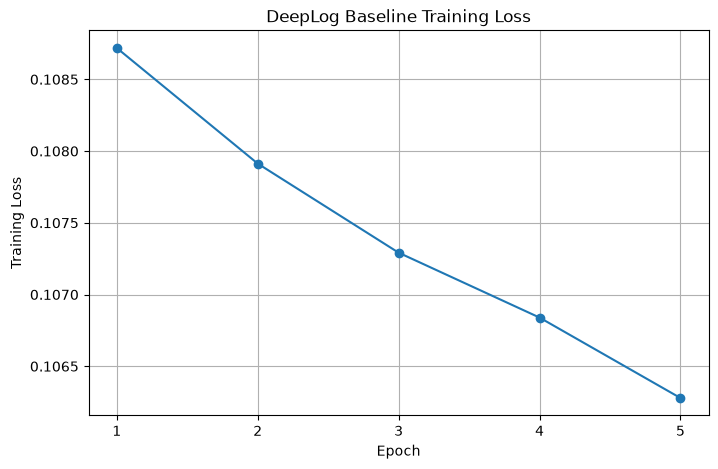

In [19]:
# ============================================
# DeepLog Training Loss Curve
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DeepLog Baseline Training Loss")

plt.xticks(range(1, len(training_losses) + 1))
plt.grid(True)

plt.show()

In [20]:
# ============================================
# Save Trained DeepLog Model
# ============================================

import os
import torch

# Create models directory
os.makedirs("../models", exist_ok=True)

# Path for saved model
model_path = "../models/deeplog_baseline.pth"

# Save model weights
torch.save(model.state_dict(), model_path)

print("DeepLog model saved successfully!")
print("Model path:", model_path)

# Check file exists
if os.path.exists(model_path):
    print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

DeepLog model saved successfully!
Model path: ../models/deeplog_baseline.pth
File size: 0.24 MB


In [21]:
# ============================================
# DeepLog - Top-K Next Event Prediction
# ============================================

import torch

TOP_K = 5

def predict_top_k(model, X_data, top_k=5, batch_size=256):
    """
    Predict the top-k next-event IDs for each input sequence.
    """

    model.eval()

    predictions = []

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_data, dtype=torch.long)
    )

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():

        for (batch_x,) in loader:

            batch_x = batch_x.to(device)

            outputs = model(batch_x)

            # Get top-k predicted event IDs
            _, top_indices = torch.topk(
                outputs,
                k=top_k,
                dim=1
            )

            predictions.extend(
                top_indices.cpu().numpy()
            )

    return np.array(predictions)


print("Running Top-K prediction on test data...")

top_k_predictions = predict_top_k(
    model,
    X_test,
    top_k=TOP_K
)

print("\nTop-K prediction completed!")

print("Prediction shape:", top_k_predictions.shape)

print("\nFirst 5 predictions:")

for i in range(5):
    print(
        f"Actual event: {y_test[i]} | "
        f"Top-{TOP_K}: {top_k_predictions[i]}"
    )

Running Top-K prediction on test data...

Top-K prediction completed!
Prediction shape: (157736, 5)

First 5 predictions:
Actual event: 14 | Top-5: [14 12 24 23 13]
Actual event: 24 | Top-5: [24 16 23 12 14]
Actual event: 14 | Top-5: [14 12 24 13 16]
Actual event: 14 | Top-5: [14 23 24 12 13]
Actual event: 16 | Top-5: [16 12 24 23 26]


In [22]:
# DeepLog anomaly detection
# A window is anomalous if the actual next event
# is NOT among the Top-K predicted events.

window_anomalies = []

for i in range(len(y_test)):
    actual_event = y_test[i]
    predicted_events = top_k_predictions[i]

    is_anomaly = actual_event not in predicted_events
    window_anomalies.append(is_anomaly)

window_anomalies = np.array(window_anomalies)

print("Anomaly detection completed!")
print("Total test windows:", len(window_anomalies))
print("Normal windows:", np.sum(~window_anomalies))
print("Anomalous windows:", np.sum(window_anomalies))

print("\nAnomaly rate:",
      round(np.mean(window_anomalies) * 100, 2), "%")

print("\nFirst 10 results:")
for i in range(10):
    print(
        f"Actual: {y_test[i]} | "
        f"Top-{TOP_K}: {top_k_predictions[i]} | "
        f"Anomaly: {window_anomalies[i]}"
    )

Anomaly detection completed!
Total test windows: 157736
Normal windows: 156970
Anomalous windows: 766

Anomaly rate: 0.49 %

First 10 results:
Actual: 14 | Top-5: [14 12 24 23 13] | Anomaly: False
Actual: 24 | Top-5: [24 16 23 12 14] | Anomaly: False
Actual: 14 | Top-5: [14 12 24 13 16] | Anomaly: False
Actual: 14 | Top-5: [14 23 24 12 13] | Anomaly: False
Actual: 16 | Top-5: [16 12 24 23 26] | Anomaly: False
Actual: 14 | Top-5: [14 12 13 24 21] | Anomaly: False
Actual: 16 | Top-5: [16 12 24 14 23] | Anomaly: False
Actual: 16 | Top-5: [16 12 24 23 18] | Anomaly: False
Actual: 16 | Top-5: [16 12 23 24 14] | Anomaly: False
Actual: 12 | Top-5: [16 12 24 23 14] | Anomaly: False


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert ground-truth labels into binary labels
# Success = 0 (normal)
# Fail = 1 (anomalous)

y_true_binary = np.array([
    1 if label == "Fail" else 0
    for label in labels_test
])

# DeepLog window-level anomaly predictions
y_pred_binary = window_anomalies.astype(int)

accuracy = accuracy_score(y_true_binary, y_pred_binary)
precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

print("DeepLog Baseline Evaluation")
print("=" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

DeepLog Baseline Evaluation
Accuracy : 0.9314
Precision: 0.9713
Recall   : 0.0644
F1 Score : 0.1208


Confusion Matrix:
[[146165     22]
 [ 10805    744]]


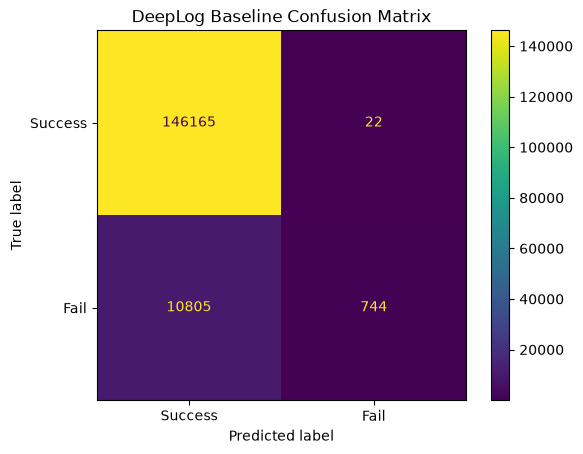

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Success", "Fail"]
)

disp.plot()
plt.title("DeepLog Baseline Confusion Matrix")
plt.show()

In [25]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

# Save metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_path = "../results/deeplog_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

# Save confusion matrix
cm_df = pd.DataFrame(
    cm,
    index=["Actual Success", "Actual Fail"],
    columns=["Predicted Success", "Predicted Fail"]
)

cm_path = "../results/confusion_matrix.csv"
cm_df.to_csv(cm_path)

print("Evaluation results saved successfully!")
print("\nMetrics:")
print(metrics_df)

print("\nConfusion Matrix:")
print(cm_df)

Evaluation results saved successfully!

Metrics:
      Metric     Value
0   Accuracy  0.931360
1  Precision  0.971279
2     Recall  0.064421
3   F1 Score  0.120828

Confusion Matrix:
                Predicted Success  Predicted Fail
Actual Success             146165              22
Actual Fail                 10805             744


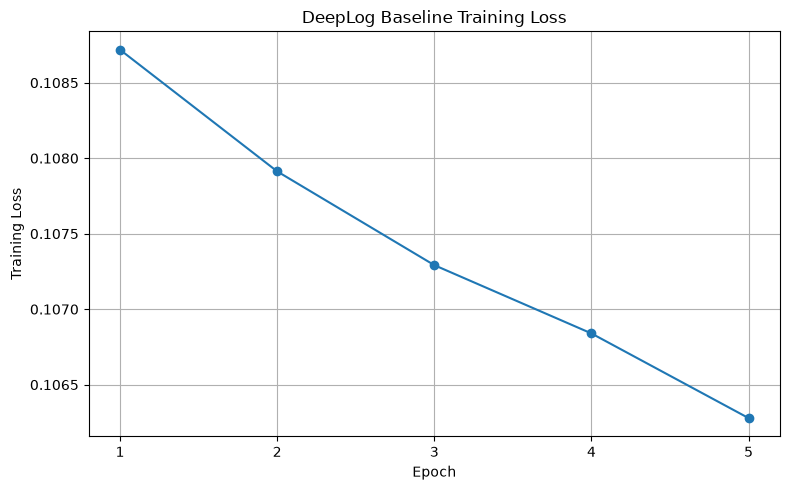

<Figure size 700x600 with 0 Axes>

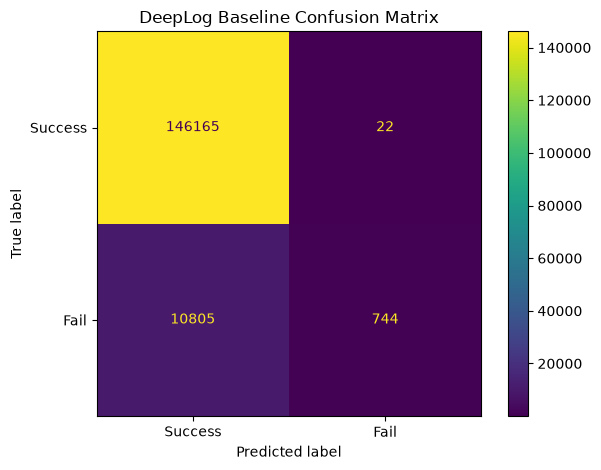

Plots saved successfully!
Training curve: ../results/training_loss_curve.png
Confusion matrix: ../results/confusion_matrix.png


In [26]:
# Save training loss curve
training_curve_path = "../results/training_loss_curve.png"

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(training_losses) + 1),
    training_losses,
    marker="o"
)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("DeepLog Baseline Training Loss")
plt.xticks(range(1, len(training_losses) + 1))
plt.grid(True)
plt.tight_layout()
plt.savefig(training_curve_path, dpi=300)
plt.show()


# Save confusion matrix figure
confusion_matrix_path = "../results/confusion_matrix.png"

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Success", "Fail"]
)
disp.plot()
plt.title("DeepLog Baseline Confusion Matrix")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Plots saved successfully!")
print("Training curve:", training_curve_path)
print("Confusion matrix:", confusion_matrix_path)

In [27]:
id="m2summary"
# Create a final Markdown summary for the M2 deliverable

summary_path = "../results/M2_Baseline_Results.md"

summary = f"""# M2 — DeepLog Baseline Reproduction

## Dataset

- Dataset: HDFS
- Total parsed blocks: 575,061
- Unique event IDs: {NUM_EVENTS}
- DeepLog window size: {WINDOW_SIZE}
- Total generated windows: {len(X)}
- Training windows: {len(X_train)}
- Testing windows: {len(X_test)}

## Model Configuration

- Model: DeepLog LSTM
- Embedding size: {EMBEDDING_SIZE}
- Hidden size: {HIDDEN_SIZE}
- LSTM layers: {NUM_LAYERS}
- Batch size: {BATCH_SIZE}
- Learning rate: 0.001
- Epochs: {EPOCHS}
- Optimizer: Adam
- Loss function: CrossEntropyLoss
- Top-K: {TOP_K}
- Device: {device}

## Evaluation Results

| Metric | Value |
|---|---:|
| Accuracy | {accuracy:.4f} |
| Precision | {precision:.4f} |
| Recall | {recall:.4f} |
| F1 Score | {f1:.4f} |

## Confusion Matrix

|  | Predicted Success | Predicted Fail |
|---|---:|---:|
| Actual Success | {cm[0,0]} | {cm[0,1]} |
| Actual Fail | {cm[1,0]} | {cm[1,1]} |

## Training

The DeepLog LSTM was trained using only training windows associated
with normal (Success) sequences.

The training loss curve is saved as:

`training_loss_curve.png`

## Evaluation

DeepLog identifies a window as anomalous when the actual next event
does not appear among the Top-{TOP_K} predicted events.

The confusion matrix is saved as:

`confusion_matrix.png`

## Important Note

These results represent the current baseline implementation in the
LogSentry project. The current notebook uses window-level evaluation.
Therefore, these numbers should not be described as an exact
paper-level reproduction unless the dataset split and evaluation
protocol are confirmed to match the original DeepLog experiment.

## Generated Artifacts

- `deeplog_baseline.pth`
- `deeplog_metrics.csv`
- `confusion_matrix.csv`
- `training_loss_curve.png`
- `confusion_matrix.png`
- `M2_Baseline_Results.md`
"""

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary)

print("M2 baseline summary saved successfully!")
print(summary_path)

M2 baseline summary saved successfully!
../results/M2_Baseline_Results.md


In [28]:
import os

print("=== M2 RESULTS ===")

results_dir = "../results"
for filename in sorted(os.listdir(results_dir)):
    path = os.path.join(results_dir, filename)
    size_kb = os.path.getsize(path) / 1024
    print(f"✓ {filename:<30} {size_kb:.1f} KB")

print("\n=== M2 MODEL ===")

model_dir = "../models"
for filename in sorted(os.listdir(model_dir)):
    path = os.path.join(model_dir, filename)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"✓ {filename:<30} {size_mb:.2f} MB")

print("\nM2 artifact check completed!")

=== M2 RESULTS ===
✓ M2_Baseline_Results.md         1.7 KB
✓ baseline                       0.0 KB
✓ confusion_matrix.csv           0.1 KB
✓ confusion_matrix.png           69.1 KB
✓ deeplog_metrics.csv            0.1 KB
✓ training_loss_curve.png        99.0 KB

=== M2 MODEL ===
✓ deeplog_baseline.pth           0.24 MB

M2 artifact check completed!


In [29]:
import os
import subprocess

print("=== CURRENT BRANCH ===")
print(subprocess.check_output(
    ["git", "branch", "--show-current"],
    text=True
).strip())

print("\n=== GIT STATUS ===")
print(subprocess.check_output(
    ["git", "status", "--short"],
    text=True
))

print("=== RESULTS DIRECTORY ===")
for item in sorted(os.listdir("../results")):
    path = os.path.join("../results", item)
    print(f"{item} -> {'DIRECTORY' if os.path.isdir(path) else 'FILE'}")

print("\n=== MODELS DIRECTORY ===")
for item in sorted(os.listdir("../models")):
    path = os.path.join("../models", item)
    print(f"{item} -> {'DIRECTORY' if os.path.isdir(path) else 'FILE'}")

=== CURRENT BRANCH ===
member2-baseline

=== GIT STATUS ===
?? 02_DeepLog_Baseline.ipynb
?? Data
?? Event_traces.csv
?? LogSentry-Capstone/
?? anomaly_label.csv
?? evaluation_results.csv
?? models/

=== RESULTS DIRECTORY ===
M2_Baseline_Results.md -> FILE
baseline -> DIRECTORY
confusion_matrix.csv -> FILE
confusion_matrix.png -> FILE
deeplog_metrics.csv -> FILE
training_loss_curve.png -> FILE

=== MODELS DIRECTORY ===
deeplog_baseline.pth -> FILE


In [30]:
import os
import subprocess

print("=== GIT ROOT ===")
git_root = subprocess.check_output(
    ["git", "rev-parse", "--show-toplevel"],
    text=True
).strip()
print(git_root)

print("\n=== NOTEBOOK WORKING DIRECTORY ===")
print(os.getcwd())

print("\n=== UNTRACKED FILES/FOLDERS ===")
status = subprocess.check_output(
    ["git", "status", "--short"],
    text=True
)

print(status)

print("\n=== .GITIGNORE ===")
gitignore_path = os.path.join(git_root, ".gitignore")

if os.path.exists(gitignore_path):
    with open(gitignore_path, "r", encoding="utf-8") as f:
        print(f.read())
else:
    print("No .gitignore found at Git root.")

=== GIT ROOT ===
C:/Users/shris/LogSentry-Capstone

=== NOTEBOOK WORKING DIRECTORY ===
c:\Users\shris\LogSentry-Capstone

=== UNTRACKED FILES/FOLDERS ===
?? 02_DeepLog_Baseline.ipynb
?? Data
?? Event_traces.csv
?? LogSentry-Capstone/
?? anomaly_label.csv
?? evaluation_results.csv
?? models/


=== .GITIGNORE ===
No .gitignore found at Git root.


In [31]:
import os

repo_root = os.getcwd()
parent_dir = os.path.dirname(repo_root)

print("=== REPOSITORY ROOT ===")
print(repo_root)

print("\n=== RESULTS IN REPOSITORY ===")
repo_results = os.path.join(repo_root, "results")
print("Exists:", os.path.exists(repo_results))
if os.path.exists(repo_results):
    for item in sorted(os.listdir(repo_results)):
        print("  ", item)

print("\n=== MODELS IN REPOSITORY ===")
repo_models = os.path.join(repo_root, "models")
print("Exists:", os.path.exists(repo_models))
if os.path.exists(repo_models):
    for item in sorted(os.listdir(repo_models)):
        print("  ", item)

print("\n=== RESULTS OUTSIDE REPOSITORY ===")
parent_results = os.path.join(parent_dir, "results")
print("Exists:", os.path.exists(parent_results))
if os.path.exists(parent_results):
    for item in sorted(os.listdir(parent_results)):
        print("  ", item)

print("\n=== MODELS OUTSIDE REPOSITORY ===")
parent_models = os.path.join(parent_dir, "models")
print("Exists:", os.path.exists(parent_models))
if os.path.exists(parent_models):
    for item in sorted(os.listdir(parent_models)):
        print("  ", item)

=== REPOSITORY ROOT ===
c:\Users\shris\LogSentry-Capstone

=== RESULTS IN REPOSITORY ===
Exists: False

=== MODELS IN REPOSITORY ===
Exists: True
   deeplog_baseline.pth

=== RESULTS OUTSIDE REPOSITORY ===
Exists: True
   M2_Baseline_Results.md
   baseline
   confusion_matrix.csv
   confusion_matrix.png
   deeplog_metrics.csv
   training_loss_curve.png

=== MODELS OUTSIDE REPOSITORY ===
Exists: True
   deeplog_baseline.pth


In [34]:
import os
import shutil

repo_root = os.getcwd()
parent_dir = os.path.dirname(repo_root)

# Create required repository folders
repo_results = os.path.join(repo_root, "results")
repo_models = os.path.join(repo_root, "models")

os.makedirs(repo_results, exist_ok=True)
os.makedirs(repo_models, exist_ok=True)

# Copy ONLY the required M2 result artifacts
required_results = [
    "M2_Baseline_Results.md",
    "confusion_matrix.csv",
    "confusion_matrix.png",
    "deeplog_metrics.csv",
    "training_loss_curve.png"
]

for filename in required_results:
    source = os.path.join(parent_dir, "results", filename)
    destination = os.path.join(repo_results, filename)

    if os.path.exists(source):
        shutil.copy2(source, destination)
        print("Copied:", filename)
    else:
        print("WARNING - not found:", source)

# Make sure the trained model exists inside the repository
model_source = os.path.join(parent_dir, "models", "deeplog_baseline.pth")
model_destination = os.path.join(repo_models, "deeplog_baseline.pth")

if not os.path.exists(model_destination) and os.path.exists(model_source):
    shutil.copy2(model_source, model_destination)
    print("Copied model into repository.")

# Create .gitignore
gitignore_content = """# Python
.venv/
__pycache__/
*.py[cod]

# Jupyter
.ipynb_checkpoints/

# Raw / large datasets
Data/
data/
*.zip
*.csv

# Generated model files
models/*.pt
models/*.pth

# Generated results
results/

# Temporary files
*.tmp
*.log
"""

# We want the M2 notebook and documentation tracked,
# so explicitly allow the required M2 result files below.
gitignore_content += """
!results/
!results/M2_Baseline_Results.md
!results/confusion_matrix.csv
!results/confusion_matrix.png
!results/deeplog_metrics.csv
!results/training_loss_curve.png

# Allow the M2 model
!models/
!models/deeplog_baseline.pth
"""

gitignore_path = os.path.join(repo_root, ".gitignore")

with open(gitignore_path, "w", encoding="utf-8") as f:
    f.write(gitignore_content)

print("\nRepository preparation completed!")
print("Results:", repo_results)
print("Model:", model_destination)
print(".gitignore:", gitignore_path)

Copied: M2_Baseline_Results.md
Copied: confusion_matrix.csv
Copied: confusion_matrix.png
Copied: deeplog_metrics.csv
Copied: training_loss_curve.png

Repository preparation completed!
Results: c:\Users\shris\LogSentry-Capstone\results
Model: c:\Users\shris\LogSentry-Capstone\models\deeplog_baseline.pth
.gitignore: c:\Users\shris\LogSentry-Capstone\.gitignore


In [35]:
import subprocess

print("=== BRANCH ===")
print(subprocess.check_output(
    ["git", "branch", "--show-current"],
    text=True
).strip())

print("\n=== GIT STATUS ===")
status = subprocess.check_output(
    ["git", "status", "--short"],
    text=True
)

print(status)

print("\n=== FILES TO BE TRACKED ===")
print(subprocess.check_output(
    ["git", "status", "--short", "--untracked-files=all"],
    text=True
))

=== BRANCH ===
member2-baseline

=== GIT STATUS ===
?? .gitignore
?? 02_DeepLog_Baseline.ipynb
?? Data
?? LogSentry-Capstone/
?? models/
?? results/


=== FILES TO BE TRACKED ===
?? .gitignore
?? 02_DeepLog_Baseline.ipynb
?? Data
?? LogSentry-Capstone/
?? models/deeplog_baseline.pth
?? results/M2_Baseline_Results.md
?? results/confusion_matrix.csv
?? results/confusion_matrix.png
?? results/deeplog_metrics.csv
?? results/training_loss_curve.png



In [36]:
import os

repo_root = os.getcwd()

print("=== DATA ===")
data_path = os.path.join(repo_root, "Data")

if os.path.isdir(data_path):
    print("Data is a DIRECTORY")
    for root, dirs, files in os.walk(data_path):
        level = root.replace(data_path, "").count(os.sep)
        if level > 1:
            dirs[:] = []
            continue
        print("  " * level + os.path.basename(root) + "/")
        for file in files[:10]:
            print("  " * (level + 1) + file)
else:
    print("Data is a FILE")
    print("Size:", os.path.getsize(data_path) / (1024 * 1024), "MB")

print("\n=== NESTED LogSentry-Capstone ===")
nested_path = os.path.join(repo_root, "LogSentry-Capstone")

if os.path.isdir(nested_path):
    print("Nested directory exists.")
    print("Contains:")
    for item in os.listdir(nested_path)[:20]:
        print("  ", item)
else:
    print("Nested directory does not exist.")

=== DATA ===
Data is a FILE
Size: 0.0 MB

=== NESTED LogSentry-Capstone ===
Nested directory exists.
Contains:
   .git
   .venv
   data
   models
   notebooks
   README.md
   results
